# 三维金（Au）超表面：从 HDF5 导入材料

本示例保留 `complex-permittivity-metasurface-3d.ipynb` 的网格、波源、几何、反射/透射检测平面以及 Ex 显示平面，只把金的材料构造方式改为从外部 HDF5 文件读取。原 notebook 不会被修改。

材料文件为 `examples/gold_rakic_1998.h5`，采用 `fdtdz.materials` schema version 1。`gold` 位于 `/materials/000000`；`eps_inf` 位于 `/materials/000000/eps_inf`；一个 Drude 极点和五个 Lorentz 极点依次位于 `/materials/000000/poles/000000` 至 `/materials/000000/poles/000005`。极点类型保存在各极点组的 `model` 属性中，各常数保存在同名标量 dataset 中。

HDF5 中保存的是适用于本仿真的**归一化求解器参数**，对应一个长度单位 48 nm、一个时间单位 48 nm/c₀。数据由 `examples/create_gold_material_hdf5.py` 根据 Rakić 等人的 Lorentz–Drude 金参数生成：$\varepsilon_\infty=1$、$\hbar\omega_p=9.03\,\mathrm{eV}$，包含一个 Drude 极点和五个 Lorentz 极点。800 nm 处解析相对介电常数约为 **−20.2777 + 2.0706i**。

运行四个代码单元格：检查 GPU；读取 HDF5 并运行仿真；绘制检测截面上的 Ex；保存结果。需要重新生成材料文件时运行 `python examples/create_gold_material_hdf5.py`。

来源：A. D. Rakić et al., *Optical properties of metallic films for vertical-cavity optoelectronic devices*, Applied Optics **37**, 5271–5283 (1998)，表 1、表 2。[论文 DOI](https://doi.org/10.1364/AO.37.005271)


In [1]:
# 1. 系统与 GPU 检查
from pathlib import Path
import os
import sys

# 在导入 JAX 前设置，避免其一次性占用整张 GPU。
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")
import jax

def find_repo_root():
    configured = os.environ.get("FDTDZ_REPO_ROOT")
    candidates = [] if configured is None else [Path(configured)]
    candidates += [Path.cwd(), Path.cwd() / "fdtdz", *Path.cwd().parents]
    candidates += [Path("/mnt/e/imaginary-fdtdz/fdtdz"),
                   Path("E:/imaginary-fdtdz/fdtdz")]
    for candidate in candidates:
        if (candidate / "src" / "fdtdz_jax").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("找不到 src/fdtdz_jax；请在项目目录启动 Jupyter，或设置 FDTDZ_REPO_ROOT。")

REPO_ROOT = find_repo_root()
SOURCE_ROOT = str(REPO_ROOT / "src")
if SOURCE_ROOT not in sys.path:
    sys.path.insert(0, SOURCE_ROOT)

gpu_devices = [device for device in jax.devices()
               if device.platform in ("gpu", "cuda", "rocm")]
print("Python:", sys.executable)
print("JAX devices:", jax.devices())
if not gpu_devices:
    raise RuntimeError("当前 kernel 未检测到 GPU；请切换到安装了 GPU 版 JAX 的 kernel。")


Python: /mnt/e/imaginary-fdtdz/fdtdz/.venv-wsl/bin/python
JAX devices: [cuda(id=0)]


In [2]:
# 2. 从 HDF5 读取金材料，并使用与原示例相同的波源、几何和检测平面
import numpy as np
import matplotlib.pyplot as plt
from fdtdz_jax import (
    BoundarySpec3D, CylinderZ3D, GridSpec3D, Layer3D,
    Lossless, PhysicalScale, PlaneWaveSource3D,
    ScatteringMonitor3D, Simulation3D, read_material,
)

# These values are intentionally identical to the original notebook.
BASE_GRID_SHAPE = (8, 8, 96)
GRID_REFINEMENT = 4
DT = 0.45
NUM_STEPS = 240
LENGTH_UNIT_M = 48e-9
SOURCE_WAVELENGTH_M = 800e-9
physical_scale = PhysicalScale(length_unit_m=LENGTH_UNIT_M)
SOURCE_FREQUENCY = float(1.0 / physical_scale.wavelength(SOURCE_WAVELENGTH_M))
BASE_DISPLAY_Z_INDEX = 50
BASE_DISPLAY_SNAPSHOT_STEP = 120

def gaussian_pulse(num_steps, dt, frequency, center=18.0, width=6.0):
    time = np.arange(num_steps) * dt
    return np.exp(-0.5 * ((time - center) / width)**2) * np.sin(
        2.0 * np.pi * frequency * (time - center))

air = Lossless(1.0)
substrate = Lossless(2.25)
gold_material_file = REPO_ROOT / "examples" / "gold_rakic_1998.h5"
gold = read_material(gold_material_file, "gold")
print("Loaded Au material:", gold_material_file)
print("Pole count:", len(gold.poles))

source_omega = 2.0 * np.pi * SOURCE_FREQUENCY
gold_eps_at_source = complex(gold.relative_permittivity(source_omega))
print(f"Au at {SOURCE_WAVELENGTH_M * 1e9:.0f} nm: "
      f"epsilon_r = {gold_eps_at_source.real:.4f} "
      f"+ {gold_eps_at_source.imag:.4f}i")
waveform = gaussian_pulse(NUM_STEPS, DT, SOURCE_FREQUENCY)

base_simulation = Simulation3D(
    GridSpec3D(shape=BASE_GRID_SHAPE, spacing=(1.0, 1.0, 1.0), dt=DT),
    BoundarySpec3D(cpml_width=12, target_reflection=1e-8),
    background=air, backend="jax", dtype=np.float32)
base_simulation.add_material("substrate", substrate)
base_simulation.add_material("gold", gold)
base_simulation.add_geometry(Layer3D(
    z_min=47.0, z_max=50.0, material="substrate"))
base_simulation.add_geometry(CylinderZ3D(
    center_xy=(4.0, 4.0), radius=2.4, z_center=48.5, height=3.0,
    material="gold"))
# Same source plane, waveform, x polarization, and +z direction.
base_simulation.set_source(PlaneWaveSource3D(
    waveform, z_index=20, polarization_xy=(1.0, 0.0), direction=1))
# Same reflection/transmission planes and Ex snapshot step.
base_simulation.set_monitors(ScatteringMonitor3D(
    reflection_z=32, transmission_z=72,
    snapshot_steps=(BASE_DISPLAY_SNAPSHOT_STEP,)))

simulation = base_simulation.refined(GRID_REFINEMENT)
DISPLAY_Z_INDEX = BASE_DISPLAY_Z_INDEX * GRID_REFINEMENT
DISPLAY_SNAPSHOT_STEP = BASE_DISPLAY_SNAPSHOT_STEP * GRID_REFINEMENT
result = simulation.run(window="hann")


Loaded Au material: /mnt/e/imaginary-fdtdz/fdtdz/examples/gold_rakic_1998.h5
Pole count: 6
Au at 800 nm: epsilon_r = -20.2777 + 2.0706i


complex-permittivity-metasurface-3d-hdf5.ipynb:cell-3:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


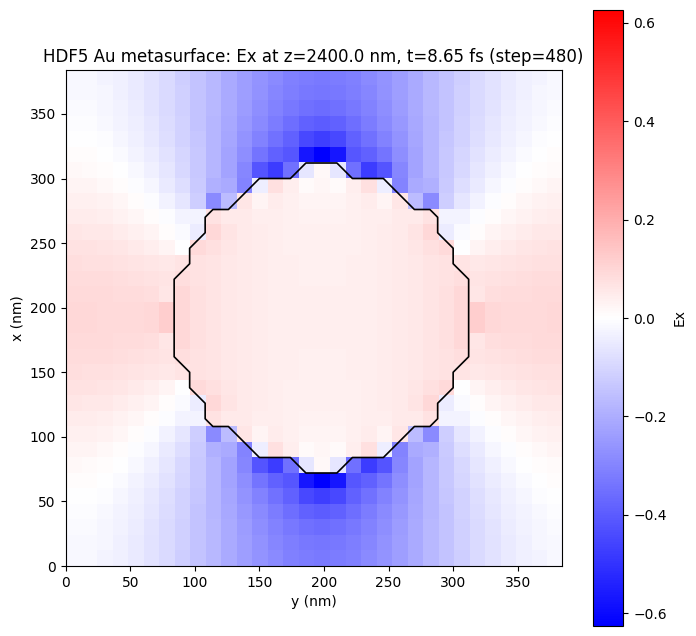

In [3]:
# 3. 检测截面上的电场 Ex（绘图参数与原示例相同）
field = result.snapshot_field("Ex")[0, :, :, DISPLAY_Z_INDEX]
field_limit = max(float(np.max(np.abs(field))), np.finfo(float).eps)
extent = (0.0, float(physical_scale.metres(result.grid.extent[1])) * 1e9,
          0.0, float(physical_scale.metres(result.grid.extent[0])) * 1e9)
gold_id = result.material_names.index("gold")
gold_mask = result.material_ids[0, :, :, DISPLAY_Z_INDEX] == gold_id

plt.figure(figsize=(8, 8))
field_image = plt.imshow(
    field, origin="lower", aspect="equal", cmap="bwr",
    vmin=-field_limit, vmax=field_limit, extent=extent,
    interpolation="none")
plt.contour(gold_mask, levels=(0.5,), colors="black", linewidths=1.2,
            origin="lower", extent=extent)
plt.colorbar(field_image, label="Ex")
plt.xlabel("y (nm)")
plt.ylabel("x (nm)")
plt.title(
    f"HDF5 Au metasurface: Ex at z="
    f"{float(physical_scale.metres(DISPLAY_Z_INDEX * result.grid.dz)) * 1e9:.1f} nm, "
    f"t={float(physical_scale.seconds(result.snapshot_times[0])) * 1e15:.2f} fs "
    f"(step={DISPLAY_SNAPSHOT_STEP})")
plt.show()


In [4]:
# 4. 保存 HDF5 材料来源和 Ex 仿真结果
OUTPUT_DIRECTORY = REPO_ROOT / "outputs"
OUTPUT_DIRECTORY.mkdir(exist_ok=True)
output_file = OUTPUT_DIRECTORY / "metasurface_3d_hdf5_result.npz"
np.savez_compressed(
    output_file,
    length_unit_m=LENGTH_UNIT_M,
    time_unit_s=physical_scale.time_unit_s,
    grid_spacing=np.asarray(result.grid.spacing),
    dt=result.grid.dt,
    source_wavelength_m=SOURCE_WAVELENGTH_M,
    material_names=np.asarray(result.material_names),
    gold_material_file=str(gold_material_file),
    gold_eps_inf=gold.eps_inf,
    gold_eps_at_source=np.asarray(gold_eps_at_source),
    material_ids=result.material_ids,
    snapshot_steps=result.snapshots.steps,
    snapshot_ex=field,
    snapshot_electric=result.snapshots.electric,
    final_electric=result.final_state.electric,
    final_magnetic=result.final_state.magnetic,
    final_displacement=result.final_state.displacement,
    final_polarization=result.final_polarization(),
)
print("已保存:", output_file)


已保存: /mnt/e/imaginary-fdtdz/fdtdz/outputs/metasurface_3d_hdf5_result.npz
